# Mapa del sismo: epicentro y estaciones acelerográficas

Dibuja dos mapas de un sismo con su epicentro y las estaciones cuyos registros se comparan:

1. **Colombia**: todo el país, con un recuadro punteado que marca la zona del mapa regional.
2. **Regional**: acercamiento automático alrededor del epicentro y de las estaciones.

| Símbolo | Qué es |
|---|---|
| ★ estrella roja | Epicentro |
| ▲ triángulo con el código adentro | Estación acelerográfica del SGC |
| ■ cuadrado con el código adentro | Acelerógrafo UdeA |

Si dos símbolos se tapan, el notebook los separa lo justo. Cuando un símbolo se mueve más de la mitad de su tamaño, una línea delgada lo une con su ubicación real (punto negro). En el mapa regional los símbolos casi nunca se mueven, así que ese mapa muestra la posición exacta. La leyenda trae la distancia epicentral de cada estación.

Los límites departamentales van en violeta, como en los mapas de OpenStreetMap/Leaflet, y cada departamento lleva su nombre. El mapa regional muestra además los municipios más poblados (5 por defecto) de los departamentos del epicentro y de las estaciones, con la capital en negrilla. Los nombres se acomodan para no tapar los símbolos ni taparse entre sí.

### Para otro sismo
1. Editar solo la configuración (§3): `SISMO`, `DIR_SGC`, `EVENTO` y `ESTACIONES`.
2. Lo que se deje en `None` (coordenadas, profundidad, magnitud, hora UTC, lugar) se toma de la cabecera de los `.anc` del SGC que están en `DIR_SGC`. El archivo de cada estación se busca por el final `_<CODIGO>_<LOC>.anc`, igual que en `plantilla_analisis_sismo.ipynb`. Las coordenadas del Acelerógrafo UdeA siempre se escriben a mano.
3. **Run All**. Los PNG quedan en `output/<SISMO>/mapa/`.

### Requisitos
`cartopy` (instalar una sola vez con `pip install cartopy`). La primera corrida descarga:
- los límites de Natural Earth;
- con `FONDO = "relieve"`, las teselas de relieve de Esri (si no hay conexión, el mapa sale con fondo plano);
- la tabla de municipios de GeoNames, que se guarda en `data/geo/municipios_colombia.csv` y de ahí se lee en adelante. Esa tabla trae por municipio la población y la ubicación de la cabecera, y se puede corregir a mano.

## §2 Importaciones

In [1]:
# Instalar una sola vez si falta:  %pip install cartopy
import csv
import io
import math
import pathlib
import unicodedata
import zipfile
from datetime import datetime, timedelta

import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from matplotlib.font_manager import FontProperties
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.textpath import TextPath
from matplotlib.transforms import offset_copy
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.io.img_tiles import GoogleTiles
from obspy.geodetics import gps2dist_azimuth
from shapely.geometry import Point, box

from sismo_utils import buscar_anc, leer_cabecera_anc   # la misma lectura del .anc que usan las plantillas

## §3 Configuración

Lo único que se edita para un sismo nuevo. Los nombres (`SISMO`, `DIR_SGC`, `DIR_SALIDA`) son los mismos de `plantilla_analisis_sismo.ipynb`.

- `EVENTO`: datos del boletín del SGC. Lo que quede en `None` se lee del `.anc`.
- `ESTACIONES`: una entrada por estación. `tipo` es `"sgc"` (triángulo) o `"udea"` (cuadrado); `color` es el relleno del símbolo (por defecto, los mismos colores de las gráficas de estaciones juntas de la plantilla). `texto` (opcional) es lo que va dentro del símbolo si no es el código, y `"\n"` lo parte en renglones: `"PAN\nUDEA01"` achica el cuadrado.
- `DEPARTAMENTOS_MUNICIPIOS`: departamentos cuyos municipios más poblados se dibujan en el mapa regional (`None` = los del epicentro y las estaciones). `N_MUNICIPIOS` fija cuántos por departamento.
- `FONDO`: `"relieve"` (Esri World Shaded Relief, necesita internet) o `"plano"`.
- `COLOR_DEPARTAMENTOS`: color de los límites y nombres de los departamentos.
- `MARGEN_GRADOS`: margen alrededor de los puntos en el mapa regional.

In [2]:
# -- 1) Sismo y carpetas ------------------------------------------------------------------------
SISMO   = "terremoto_choco"          # nombre de la carpeta de datos y de la carpeta de salida
DIR_SGC = pathlib.Path("data/sismos") / SISMO / "sgc"
# El Chocó está en la estructura antigua. PARA UN SISMO NUEVO, BORRAR ESTA LÍNEA:
DIR_SGC = pathlib.Path("data/Datos_SGC_Terremoto_Choco")
DIR_SALIDA = pathlib.Path("output") / SISMO / "mapa"

# -- 2) Evento (None = tomarlo de la cabecera del .anc) ------------------------------------------
EVENTO = {
    "id":             "SGC2026pqqmro",
    "lugar":          "San José del Palmar - Chocó",   # el .anc trae las tildes como "?"
    "magnitud":       7.4,
    "profundidad_km": 103,
    "hora_local":     "2026-08-10 07:34:27",
    "hora_utc":       "2026-08-10 12:34:27",
    "lat":            4.99,
    "lon":            -76.29,
}
TZ_OFFSET_HORAS = -5          # hora local de Colombia = UTC-5 (si falta la hora local)

# -- 3) Estaciones (lat/lon None = tomarlas del .anc; solo estaciones del SGC) ------------------
ESTACIONES = [
    {"codigo": "CBOCA", "red": "CM", "loc": "10", "municipio": "Pereira", "departamento": "Risaralda",
     "lat": 4.78, "lon": -75.65, "tipo": "sgc", "color": "#90CAF9"},
    {"codigo": "RIO2C", "red": "CM", "loc": "10", "municipio": "Riosucio", "departamento": "Caldas",
     "lat": 5.42, "lon": -75.71, "tipo": "sgc", "color": "#A5D6A7"},
    {"codigo": "DBB", "red": "CM", "loc": "10", "municipio": "Dabeiba", "departamento": "Antioquia",
     "lat": 7.02, "lon": -76.21, "tipo": "sgc", "color": "#EF9A9A"},
    {"codigo": "PANUDEA01", "red": "PAN", "loc": "", "municipio": "Medellín", "departamento": "Antioquia",
     "lat": 6.2663, "lon": -75.56899, "tipo": "udea", "color": "#212121", "texto": "PAN\nUDEA01"},
]
# Clave opcional "texto": lo que va dentro del símbolo si no es el código; "\n" lo parte en renglones.
ETIQUETA_TIPO = {"sgc": "Estación acelerográfica SGC", "udea": "Acelerógrafo UdeA"}

# -- 4) Departamentos y municipios -------------------------------------------------------------
DEPARTAMENTOS_MUNICIPIOS = None      # None = los del epicentro y las estaciones; o p. ej. ["Chocó", "Antioquia"]
N_MUNICIPIOS = 5                     # municipios más poblados de cada departamento
DIR_GEO = pathlib.Path("data/geo")   # aquí se guarda la tabla de municipios la primera vez

# -- 5) Mapa -------------------------------------------------------------------------------------
FONDO = "relieve"                               # "relieve" o "plano"
COLOR_DEPARTAMENTOS = "#9C3D9C"                 # violeta de los límites administrativos de OpenStreetMap
MARGEN_GRADOS = 0.6                             # margen del mapa regional alrededor de los puntos
EXTENSION_COLOMBIA = [-79.8, -66.5, -4.5, 13.0] # lon_min, lon_max, lat_min, lat_max
DPI = 300

## §4 Completar datos desde los `.anc` y distancias

Llena con la cabecera de los `.anc` lo que quedó en `None` en la configuración y calcula para cada estación la distancia epicentral, la distancia hipocentral y el azimut desde el epicentro.

In [3]:
FMT_FECHA = "%Y-%m-%d %H:%M:%S"


def completar_desde_anc():
    anc_evento = None
    for est in ESTACIONES:
        ruta = buscar_anc(DIR_SGC, est["codigo"], est.get("loc", "10")) if est["tipo"] == "sgc" and DIR_SGC.exists() else None
        if ruta is None:
            continue
        cabecera = leer_cabecera_anc(ruta)
        anc_evento = anc_evento or (ruta, cabecera)
        for clave in ("lat", "lon"):
            if est.get(clave) is None:
                est[clave] = cabecera[f"{clave}_estacion"]
                print(f"{est['codigo']}: {clave} = {est[clave]} (de {ruta.name})")

    campos_anc = ("lat", "lon", "profundidad_km", "lugar", "hora_utc", "magnitud")
    if anc_evento is not None and any(EVENTO.get(k) is None for k in campos_anc):
        ruta, cabecera = anc_evento
        leidos = {"lat": cabecera["lat_evento"], "lon": cabecera["lon_evento"],
                  "profundidad_km": cabecera["profundidad_km"], "lugar": cabecera["descripcion_evento"],
                  "hora_utc": cabecera["evento_datetime_utc"].strftime(FMT_FECHA), "magnitud": cabecera["magnitud"]}
        for clave, valor in leidos.items():
            if EVENTO.get(clave) is None:
                EVENTO[clave] = valor
                print(f"Evento: {clave} = {valor} (de {ruta.name})")

    if EVENTO.get("hora_local") is None and EVENTO.get("hora_utc"):
        local = datetime.strptime(EVENTO["hora_utc"], FMT_FECHA) + timedelta(hours=TZ_OFFSET_HORAS)
        EVENTO["hora_local"] = local.strftime(FMT_FECHA)

    faltan = [f"EVENTO['{k}']" for k in ("lat", "lon") if EVENTO.get(k) is None]
    faltan += [f"{e['codigo']}.{k}" for e in ESTACIONES for k in ("lat", "lon") if e.get(k) is None]
    if faltan:
        raise ValueError(f"Faltan coordenadas (no están en la configuración ni en un .anc de {DIR_SGC}): {faltan}")


completar_desde_anc()

for est in ESTACIONES:
    metros, azimut, _ = gps2dist_azimuth(EVENTO["lat"], EVENTO["lon"], est["lat"], est["lon"])
    est["dist_km"] = metros / 1000
    est["azimut"] = azimut
    est["hipo_km"] = math.hypot(est["dist_km"], EVENTO.get("profundidad_km") or 0)

print(f"\nEpicentro: {EVENTO['lat']:.4f}, {EVENTO['lon']:.4f} · profundidad {EVENTO.get('profundidad_km')} km\n")
print(f"{'Código':<10} {'Municipio':<22} {'Lat':>8} {'Lon':>10} {'Dist. epi':>10} {'Dist. hipo':>11} {'Azimut':>7}")
for est in ESTACIONES:
    print(f"{est['codigo']:<10} {est['municipio'] + ', ' + est['departamento']:<22} {est['lat']:>8.4f} {est['lon']:>10.4f} "
          f"{est['dist_km']:>7.1f} km {est['hipo_km']:>8.1f} km {est['azimut']:>6.0f}°")


Epicentro: 4.9900, -76.2900 · profundidad 103 km

Código     Municipio                   Lat        Lon  Dist. epi  Dist. hipo  Azimut
CBOCA      Pereira, Risaralda       4.7800   -75.6500    74.7 km    127.2 km    108°
RIO2C      Riosucio, Caldas         5.4200   -75.7100    80.0 km    130.4 km     53°
DBB        Dabeiba, Antioquia       7.0200   -76.2100   224.7 km    247.2 km      2°
PANUDEA01  Medellín, Antioquia      6.2663   -75.5690   162.2 km    192.1 km     29°


## §5 Departamentos y municipios

- **Departamentos**: polígonos de Natural Earth (10m). Con ellos se sabe en qué departamento están el epicentro y cada estación.
- **Municipios**: tabla de GeoNames (`CO.zip`, licencia CC BY 4.0). Trae la población de cada municipio y la ubicación de su cabecera. La primera vez se descarga y se guarda en `data/geo/municipios_colombia.csv`; si se corrige algo en ese archivo, el notebook usa la versión corregida. Para volver a descargarla, se borra el archivo.
- De cada departamento de `DEPARTAMENTOS_MUNICIPIOS` se toman los `N_MUNICIPIOS` municipios más poblados.

In [4]:
URL_GEONAMES = "https://download.geonames.org/export/dump/CO.zip"
ARCHIVO_MUNICIPIOS = DIR_GEO / "municipios_colombia.csv"
NOMBRE_DEPARTAMENTO = {"Bogota": "Bogotá D.C.", "San Andrés y Providencia": "San Andrés"}


def sin_tildes(texto):
    return unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode().lower().strip()


def cargar_departamentos():
    """Polígonos de los departamentos de Colombia (Natural Earth) con su código de departamento de GeoNames."""
    lector = shpreader.Reader(shpreader.natural_earth("10m", "cultural", "admin_1_states_provinces"))
    departamentos = []
    for registro in lector.records():
        a = registro.attributes
        if a["adm0_a3"] != "COL" or not a["name"]:
            continue
        departamentos.append({"nombre": NOMBRE_DEPARTAMENTO.get(a["name"], a["name"]),
                              "codigo": a["gn_a1_code"].split(".")[-1],
                              "lon": a["longitude"], "lat": a["latitude"], "geometria": registro.geometry})
    return departamentos


def construir_tabla_municipios():
    """Descarga GeoNames y guarda un municipio por fila: su población y la ubicación de su cabecera."""
    print(f"Descargando {URL_GEONAMES} ...")
    respuesta = requests.get(URL_GEONAMES, timeout=120)
    respuesta.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(respuesta.content)) as z:
        filas = [linea.split("\t") for linea in z.read("CO.txt").decode("utf-8").splitlines()]
    # Columnas de GeoNames: 1 nombre, 4 lat, 5 lon, 6 clase, 7 código, 10 departamento, 11 municipio, 14 población
    lugares = {}
    for f in filas:
        if f[6] == "P" and f[11]:
            lugares.setdefault((f[10], f[11]), []).append(f)
    nombres_dep = {d["codigo"]: d["nombre"] for d in DEPARTAMENTOS}
    tabla = []
    for f in filas:
        if f[7] != "ADM2":
            continue
        candidatos = lugares.get((f[10], f[11]), [])
        # la cabecera es la sede del municipio (PPLA2), la capital del departamento (PPLA) o Bogotá (PPLC);
        # si GeoNames no la marca así, el poblado con el mismo nombre del municipio
        sedes = ([c for c in candidatos if c[7] in ("PPLC", "PPLA", "PPLA2")]
                 or [c for c in candidatos if sin_tildes(c[1]) == sin_tildes(f[1])])
        sede = max(sedes, key=lambda c: int(c[14] or 0)) if sedes else f
        tabla.append({"departamento": nombres_dep.get(f[10], f[10]),
                      "municipio": sede[1] if sin_tildes(sede[1]) == sin_tildes(f[1]) else f[1],
                      "poblacion": int(f[14] or 0), "lat": float(sede[4]), "lon": float(sede[5]),
                      "capital": sede[7] in ("PPLC", "PPLA")})
    DIR_GEO.mkdir(parents=True, exist_ok=True)
    with open(ARCHIVO_MUNICIPIOS, "w", newline="", encoding="utf-8") as f:
        escritor = csv.DictWriter(f, fieldnames=list(tabla[0]))
        escritor.writeheader()
        escritor.writerows(tabla)
    print(f"Guardado {ARCHIVO_MUNICIPIOS} ({len(tabla)} municipios)")


def cargar_municipios():
    if not ARCHIVO_MUNICIPIOS.exists():
        construir_tabla_municipios()
    with open(ARCHIVO_MUNICIPIOS, encoding="utf-8") as f:
        tabla = list(csv.DictReader(f))
    for m in tabla:
        m.update(poblacion=int(m["poblacion"]), lat=float(m["lat"]), lon=float(m["lon"]),
                 capital=m["capital"] == "True")
    return tabla


def departamento_de(lon, lat):
    punto = Point(lon, lat)
    return next((d["nombre"] for d in DEPARTAMENTOS if d["geometria"].contains(punto)), None)


DEPARTAMENTOS = cargar_departamentos()
if DEPARTAMENTOS_MUNICIPIOS is None:
    puntos = [(EVENTO["lon"], EVENTO["lat"])] + [(e["lon"], e["lat"]) for e in ESTACIONES]
    DEPARTAMENTOS_ELEGIDOS = list(dict.fromkeys(filter(None, (departamento_de(*p) for p in puntos))))
else:
    DEPARTAMENTOS_ELEGIDOS = list(DEPARTAMENTOS_MUNICIPIOS)

TABLA_MUNICIPIOS = cargar_municipios()
MUNICIPIOS = []
for dep in DEPARTAMENTOS_ELEGIDOS:
    del_dep = [m for m in TABLA_MUNICIPIOS if sin_tildes(m["departamento"]) == sin_tildes(dep)]
    if not del_dep:
        print(f"Aviso: no hay municipios de '{dep}' en {ARCHIVO_MUNICIPIOS}")
    MUNICIPIOS += sorted(del_dep, key=lambda m: -m["poblacion"])[:N_MUNICIPIOS]

print(f"Departamentos con municipios: {', '.join(DEPARTAMENTOS_ELEGIDOS)}\n")
print(f"{'Departamento':<14} {'Municipio':<22} {'Población':>10} {'Lat':>8} {'Lon':>9}")
for m in MUNICIPIOS:
    nombre = m["municipio"] + (" (capital)" if m["capital"] else "")
    print(f"{m['departamento']:<14} {nombre:<22} {m['poblacion']:>10,} {m['lat']:>8.4f} {m['lon']:>9.4f}")

Departamentos con municipios: Chocó, Risaralda, Caldas, Antioquia

Departamento   Municipio               Población      Lat       Lon
Chocó          Quibdó (capital)          112,886   5.6919  -76.6583
Chocó          Medio Atrato               29,487   5.9946  -76.7812
Chocó          Alto Baudo                 28,961   5.5162  -76.9743
Chocó          Istmina                    23,639   5.1596  -76.6861
Chocó          Bajo Baudó                 18,561   4.9550  -77.3641
Risaralda      Pereira (capital)         467,269   4.8143  -75.6949
Risaralda      Dosquebradas              179,301   4.8366  -75.6693
Risaralda      Santa Rosa de Cabal        69,960   4.8689  -75.6219
Risaralda      Quinchía                   33,318   5.3395  -75.7296
Risaralda      Belén de Umbría            27,717   5.2020  -75.8675
Caldas         Manizales (capital)       434,403   5.0668  -75.5068
Caldas         La Dorada                  72,925   5.4478  -74.6631
Caldas         Riosucio                   54,537 

## §6 Funciones de dibujo

- `agregar_fondo()`: relieve de Esri (o colores planos), mar, costas y fronteras de Natural Earth. Los límites departamentales van en violeta con un halo suave. Los países vecinos se aclaran para resaltar Colombia.
- `dibujar_simbolos()`: estrella del epicentro, triángulos del SGC y cuadrado de la UdeA con el código adentro. El tamaño de cada símbolo se ajusta al texto, y los símbolos que se tapan se separan.
- `agregar_municipios()` y `agregar_nombres_departamentos()`: escriben los nombres. Para cada uno prueban varias posiciones y eligen la que menos tapa los símbolos, la barra de escala y los nombres ya puestos. El nombre de un departamento se busca dentro de él; si no cabe (departamentos pequeños tapados por los símbolos), va afuera con una línea violeta hacia el departamento. Un municipio cuyo nombre queda lejos de su punto se une a él con una línea gris. Los municipios que caen fuera del mapa no se dibujan.
- `dibujar_mapa()`: arma una figura completa (cuadrícula, barra de escala, leyenda y título) y la guarda en PNG.

In [5]:
PC = ccrs.PlateCarree()
PROYECCION = ccrs.Mercator.GOOGLE        # la misma de las teselas de relieve: no hay que reproyectarlas
URL_RELIEVE = ("https://server.arcgisonline.com/ArcGIS/rest/services/"
               "World_Shaded_Relief/MapServer/tile/{z}/{y}/{x}")
CACHE_RELIEVE = pathlib.Path(cartopy.config["cache_dir"]) / "esri_world_shaded_relief"

COLOR_EPICENTRO = "#D32F2F"
COLOR_DEFECTO = {"sgc": "#81C784", "udea": "#212121"}
COLOR_BORDE   = {"sgc": "#1B2631", "udea": "#000000"}
MARCADOR      = {"sgc": "^", "udea": "s"}
FUENTE_CODIGO = FontProperties(family="DejaVu Sans", weight="bold")
HALO = [pe.withStroke(linewidth=3, foreground="white")]
ESTILO_DEPARTAMENTOS = (0, (7, 2, 1.5, 2))       # raya - punto
COLOR_TEXTO_DEPARTAMENTOS = mcolors.to_hex(np.array(mcolors.to_rgb(COLOR_DEPARTAMENTOS)) * 0.7)


def relieve_disponible():
    try:
        r = requests.get(URL_RELIEVE.format(z=0, y=0, x=0), timeout=8)
        return r.ok and r.headers.get("content-type", "").startswith("image")
    except requests.RequestException:
        return False


def extension_regional():
    """Caja con el epicentro y las estaciones más MARGEN_GRADOS; se ensancha si queda como una franja angosta."""
    lons = [EVENTO["lon"]] + [e["lon"] for e in ESTACIONES]
    lats = [EVENTO["lat"]] + [e["lat"] for e in ESTACIONES]
    lon0, lon1 = min(lons) - MARGEN_GRADOS, max(lons) + MARGEN_GRADOS
    lat0, lat1 = min(lats) - MARGEN_GRADOS, max(lats) + MARGEN_GRADOS
    falta = 0.8 * (lat1 - lat0) - (lon1 - lon0)
    if falta > 0:
        lon0, lon1 = lon0 - falta / 2, lon1 + falta / 2
    falta = 0.8 * (lon1 - lon0) - (lat1 - lat0)
    if falta > 0:
        lat0, lat1 = lat0 - falta / 2, lat1 + falta / 2
    return [lon0, lon1, lat0, lat1]


def proyectar(lon, lat):
    return PROYECCION.transform_point(lon, lat, PC)


def a_puntos(ax, lons, lats):
    """Posición en la figura, en puntos tipográficos, de coordenadas lon/lat."""
    xy = PROYECCION.transform_points(PC, np.atleast_1d(lons), np.atleast_1d(lats))[:, :2]
    return ax.transData.transform(xy) * 72 / ax.figure.dpi


def a_datos(ax, p):
    """Coordenadas del mapa (proyección) de una posición en puntos tipográficos."""
    return ax.transData.inverted().transform(np.asarray(p) * ax.figure.dpi / 72)


def caja_ejes(ax):
    """Centro y medio ancho/alto (pt) del recuadro del mapa."""
    x0, y0, x1, y1 = np.array(ax.bbox.extents) * 72 / ax.figure.dpi
    return np.array([(x0 + x1) / 2, (y0 + y1) / 2]), np.array([(x1 - x0) / 2, (y1 - y0) / 2])


def agregar_fondo(ax, extent, grosor=1.0):
    ax.set_extent(extent, crs=PC)
    tierra = cfeature.LAND.with_scale("10m")
    if USAR_RELIEVE:
        zoom = int(np.clip(round(math.log2(6 * 360 / (extent[1] - extent[0]))), 4, 12))
        ax.add_image(GoogleTiles(url=URL_RELIEVE, cache=str(CACHE_RELIEVE)), zoom)
        ax.add_feature(tierra, facecolor="#E3D3A8", edgecolor="none", alpha=0.35, zorder=1)
    else:
        ax.add_feature(tierra, facecolor="#EFE9DC", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="#CFE3F3", edgecolor="none", zorder=1)

    paises = shpreader.Reader(shpreader.natural_earth("10m", "cultural", "admin_0_countries"))
    otros = [r.geometry for r in paises.records() if r.attributes["ADM0_A3"] != "COL"]
    ax.add_geometries(otros, PC, facecolor="white", edgecolor="none", alpha=0.5, zorder=1.5)

    # Límites departamentales de Colombia al estilo de OpenStreetMap: halo ancho y suave + línea de raya y punto
    lineas = shpreader.Reader(shpreader.natural_earth("10m", "cultural", "admin_1_states_provinces_lines"))
    limites = [r.geometry for r in lineas.records() if r.attributes["ADM0_A3"] == "COL"]
    ax.add_geometries(limites, PC, facecolor="none", edgecolor=COLOR_DEPARTAMENTOS, linewidth=4.5 * grosor,
                      alpha=0.22, zorder=2)
    ax.add_geometries(limites, PC, facecolor="none", edgecolor=COLOR_DEPARTAMENTOS, linewidth=1.2 * grosor,
                      linestyle=ESTILO_DEPARTAMENTOS, zorder=2.1)
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), edgecolor="#1E1E1E", linewidth=1.4 * grosor, zorder=2.2)
    ax.add_feature(cfeature.COASTLINE.with_scale("10m"), edgecolor="#2F4F6F", linewidth=0.7 * grosor, zorder=2.2)


def agregar_cuadricula(ax):
    gl = ax.gridlines(crs=PC, draw_labels=True, linewidth=0.4, color="#555555", alpha=0.5,
                      linestyle="--", zorder=3)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {"size": 8}


def barra_escala(ax, extent):
    lon0, lon1, lat0, lat1 = extent
    lat_b = lat0 + 0.05 * (lat1 - lat0)
    km_por_grado = 111.32 * math.cos(math.radians(lat_b))
    objetivo = (lon1 - lon0) * km_por_grado / 5
    base = 10 ** math.floor(math.log10(objetivo))
    largo = max(m * base for m in (1, 2, 5) if m * base <= objetivo)
    x0 = lon0 + 0.05 * (lon1 - lon0)
    x1 = x0 + largo / km_por_grado
    xm = (x0 + x1) / 2
    ax.plot([x0, x1], [lat_b, lat_b], transform=PC, color="black", lw=4.5, solid_capstyle="butt", zorder=6)
    ax.plot([xm, x1], [lat_b, lat_b], transform=PC, color="white", lw=2.5, solid_capstyle="butt", zorder=7)
    x, y = proyectar(xm, lat_b)
    ax.text(x, y, f"{largo:g} km", transform=offset_copy(ax.transData, fig=ax.figure, y=6, units="points"),
            ha="center", va="bottom", fontsize=8, fontweight="bold", path_effects=HALO, zorder=7)
    (xa, ya), (xb, _) = a_puntos(ax, [x0, x1], [lat_b, lat_b])
    return np.array([(xa + xb) / 2, ya + 7]), np.array([(xb - xa) / 2 + 4, 11])   # caja que ocupa (pt)


def agregar_fuentes(ax, municipios):
    """Créditos de los datos en la esquina inferior derecha; devuelve la caja que ocupan (pt)."""
    fuentes = ["Relieve: Esri World Shaded Relief"] if USAR_RELIEVE else []
    fuentes.append("Límites: Natural Earth")
    if municipios:
        fuentes.append("Municipios: GeoNames")
    texto = " · ".join(fuentes)
    ax.text(0.995, 0.005, texto, transform=ax.transAxes, ha="right", va="bottom", fontsize=6,
            color="#333333", zorder=13, bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5))
    ancho, alto = medir([texto], 6)
    centro, medio = caja_ejes(ax)
    esquina = centro + np.array([medio[0], -medio[1]])
    return esquina + np.array([-ancho / 2 - 3, alto / 2 + 1]), np.array([ancho / 2 + 3, alto / 2 + 1.5])


def medir(renglones, fs, peso="normal"):
    """Ancho y alto (pt) aproximados de un bloque de texto de uno o varios renglones."""
    prop = FontProperties(family="DejaVu Sans", weight=peso)
    ancho = max(TextPath((0, 0), r, size=fs, prop=prop).get_extents().width for r in renglones)
    return ancho, fs * 1.2 * len(renglones)


def area_traslape(c1, m1, c2, m2):
    """Área común de dos cajas dadas por centro y medio ancho/alto."""
    ox = min(c1[0] + m1[0], c2[0] + m2[0]) - max(c1[0] - m1[0], c2[0] - m2[0])
    oy = min(c1[1] + m1[1], c2[1] + m2[1]) - max(c1[1] - m1[1], c2[1] - m2[1])
    return ox * oy if ox > 0 and oy > 0 else 0.0


def en_zona(ax, centro, zona):
    return zona.contains(Point(*PC.transform_point(*a_datos(ax, centro), PROYECCION)))


def elegir_posicion(ax, candidatos, medio, ocupadas, zona=None):
    """Centro (pt) del candidato que menos tapa las cajas `ocupadas` sin salirse del mapa. Si se da `zona`
    (polígono lon/lat), se prefiere que el centro quede adentro. Ante un empate gana el primer candidato."""
    limites = caja_ejes(ax)
    area = 4 * medio[0] * medio[1]
    mejor, costo_mejor = candidatos[0], math.inf
    for c in candidatos:
        costo = sum(area_traslape(c, medio, *o) for o in ocupadas)
        costo += 10 * (area - area_traslape(c, medio, *limites))
        if zona is not None and not en_zona(ax, c, zona):
            costo += 0.3 * area
        if costo < costo_mejor - 1e-6:
            mejor, costo_mejor = c, costo
            if costo == 0:
                break
    return mejor


def escribir_en(ax, centro, texto, **kw):
    """Escribe `texto` centrado en una posición dada en puntos tipográficos."""
    x, y = a_datos(ax, centro)
    ax.text(x, y, texto, ha="center", va="center", **kw)


def linea_guia(ax, desde, centro, medio, **kw):
    """Línea delgada desde un punto (pt) hasta el borde más cercano de una caja de texto."""
    hasta = np.clip(desde, centro - medio, centro + medio)
    (x0, y0), (x1, y1) = a_datos(ax, desde), a_datos(ax, hasta)
    ax.plot([x0, x1], [y0, y1], solid_capstyle="round", **kw)


def agregar_municipios(ax, extent, escala, ocupadas):
    """Punto en la cabecera de cada municipio y su nombre (la capital en negrilla), del más poblado al menos.
    Si el nombre queda lejos de su punto, una línea delgada los une."""
    fs = 6.5 * escala
    visibles = [m for m in MUNICIPIOS
                if extent[0] <= m["lon"] <= extent[1] and extent[2] <= m["lat"] <= extent[3]]
    if not visibles:
        return
    posiciones = a_puntos(ax, [m["lon"] for m in visibles], [m["lat"] for m in visibles])
    ocupadas += [(p, np.array([2.5, 2.5]) * escala) for p in posiciones]
    for i in sorted(range(len(visibles)), key=lambda i: -visibles[i]["poblacion"]):
        m, p = visibles[i], posiciones[i]
        ax.plot(*proyectar(m["lon"], m["lat"]), "o", ms=3.8 * escala, mfc="#1A1A1A", mec="white", mew=0.6, zorder=9)
        peso = "bold" if m["capital"] else "normal"
        ancho, alto = medir([m["municipio"]], fs, peso)
        medio = np.array([ancho / 2 + 1, alto / 2])
        candidatos = [p + np.array([ux * (d + medio[0]), uy * (d + medio[1])])
                      for d in (2.5, 8, 14, 20, 28)
                      for ux, uy in ((1, 0), (-1, 0), (0, 1), (0, -1), (1, 1), (-1, 1), (1, -1), (-1, -1))]
        centro = elegir_posicion(ax, candidatos, medio, ocupadas)
        ocupadas.append((centro, medio))
        if np.linalg.norm(np.clip(p, centro - medio, centro + medio) - p) > 6:
            linea_guia(ax, p, centro, medio, color="#333333", lw=0.6, zorder=8.5)
        escribir_en(ax, centro, m["municipio"], fontsize=fs, fontweight=peso, color="#1A1A1A",
                    path_effects=HALO, zorder=9.5)


def partir_nombre(nombre):
    """Parte en dos renglones los nombres largos de varias palabras."""
    palabras = nombre.split()
    if len(nombre) <= 12 or len(palabras) == 1:
        return [nombre]
    corte = min(range(1, len(palabras)),
                key=lambda i: abs(len(" ".join(palabras[:i])) - len(" ".join(palabras[i:]))))
    return [" ".join(palabras[:corte]), " ".join(palabras[corte:])]


def agregar_nombres_departamentos(ax, extent, escala, ocupadas):
    """Nombre de cada departamento visible, dentro de él. Los muy pequeños para su nombre se omiten,
    salvo los del epicentro y las estaciones."""
    fs = 8 * escala
    caja = box(extent[0], extent[2], extent[1], extent[3])
    _, medio_ejes = caja_ejes(ax)
    pt2_por_grado2 = (2 * medio_ejes[0] / (extent[1] - extent[0])) * (2 * medio_ejes[1] / (extent[3] - extent[2]))
    del_evento = {sin_tildes(n) for n in DEPARTAMENTOS_ELEGIDOS}
    zonas = [(d, d["geometria"].intersection(caja)) for d in DEPARTAMENTOS]
    for dep, zona in sorted(zonas, key=lambda t: -t[1].area):
        if zona.is_empty:
            continue
        renglones = partir_nombre(dep["nombre"].upper())
        ancho, alto = medir(renglones, fs)
        medio = np.array([ancho / 2 + 2, alto / 2 + 1])
        if sin_tildes(dep["nombre"]) not in del_evento and zona.area * pt2_por_grado2 < 6 * medio[0] * medio[1]:
            continue
        ancla = Point(dep["lon"], dep["lat"])
        if not zona.contains(ancla):
            ancla = zona.representative_point()
        p = a_puntos(ax, [ancla.x], [ancla.y])[0]
        pasos = sorted(((i, j) for i in range(-6, 7) for j in range(-6, 7)), key=lambda t: math.hypot(t[0] / 2, t[1]))
        candidatos = [p + np.array([i * medio[0] / 2, j * medio[1]]) for i, j in pasos]
        centro = elegir_posicion(ax, candidatos, medio, ocupadas, zona=zona)
        ocupadas.append((centro, medio))
        if not en_zona(ax, centro, zona):       # no cupo adentro: el nombre va afuera con una línea al departamento
            linea_guia(ax, p, centro, medio, color=COLOR_TEXTO_DEPARTAMENTOS, lw=0.7, zorder=3.9)
        escribir_en(ax, centro, "\n".join(renglones), fontsize=fs, fontstyle="italic", linespacing=1.0,
                    color=COLOR_TEXTO_DEPARTAMENTOS, path_effects=HALO, zorder=4)


def medir_texto(texto, fs):
    """Ancho, alto y base (en puntos) del texto en negrilla."""
    ext = TextPath((0, 0), texto, size=fs, prop=FUENTE_CODIGO).get_extents()
    return ext.width, ext.height, ext.y0


def geometria_simbolo(est, escala):
    """Tamaño de letra, tamaño del símbolo, renglones del texto y altura de la línea base de cada
    renglón respecto al centro del símbolo (pt). El texto es `texto` (o el código); "\n" parte renglones."""
    fs = 6.5 * escala
    renglones = est.get("texto", est["codigo"]).split("\n")
    medidas = [medir_texto(r, fs) for r in renglones]
    h = max(m[1] for m in medidas)                  # alto de las mayúsculas
    interlinea = 0.35 * fs
    pad = 0.35 * fs
    # altura del pie de cada renglón sobre el pie del bloque (el último renglón va abajo)
    pies = [(len(renglones) - 1 - i) * (h + interlinea) for i in range(len(renglones))]
    if est["tipo"] == "udea":
        alto = pies[0] + h
        tam = max(max(m[0] for m in medidas), alto) + 2 * pad
        pie_bloque = -alto / 2
    else:
        # El triángulo mide `tam` de base y de alto; a una altura t sobre la base mide tam - t de ancho.
        # El bloque se apoya a `margen` de la base y `tam` se elige para que cada renglón quepa a lo ancho.
        borde = 0.8
        tam = max((w + pad + borde + pie + h) / 0.9 for (w, _, _), pie in zip(medidas, pies))
        pie_bloque = -tam / 2 + 0.1 * tam + borde
    bases = [pie_bloque + pie - m[2] for m, pie in zip(medidas, pies)]
    return fs, tam, renglones, bases


def color_texto(color):
    r, g, b = mcolors.to_rgb(color)
    return "white" if 0.299 * r + 0.587 * g + 0.114 * b < 0.5 else "black"


def separar(p, medio, n_fijos=1, sep=3.0, iteraciones=500):
    """Aleja las cajas que se tapan (centro p y medio ancho/alto `medio`, en puntos).
    Cada par se separa por el eje en que menos se traslapa. Las primeras n_fijos no se mueven."""
    p = p.copy()
    for _ in range(iteraciones):
        movido = False
        for i in range(len(p)):
            for j in range(max(i + 1, n_fijos), len(p)):
                d = p[j] - p[i]
                traslape = medio[i] + medio[j] + sep - np.abs(d)
                if (traslape <= 0).any():
                    continue
                eje = int(np.argmin(traslape))
                empuje = np.zeros(2)
                empuje[eje] = traslape[eje] if d[eje] >= 0 else -traslape[eje]
                if i < n_fijos:
                    p[j] += empuje
                else:
                    p[i] -= empuje / 2
                    p[j] += empuje / 2
                movido = True
        if not movido:
            break
    return p


def dibujar_simbolos(ax, escala):
    """Dibuja epicentro y estaciones; devuelve las cajas (centro, medio ancho/alto en pt) que ocupan."""
    fig = ax.figure
    lons = np.array([EVENTO["lon"]] + [e["lon"] for e in ESTACIONES])
    lats = np.array([EVENTO["lat"]] + [e["lat"] for e in ESTACIONES])
    xy = PROYECCION.transform_points(PC, lons, lats)[:, :2]
    p0 = a_puntos(ax, lons, lats)                           # posición de cada símbolo en puntos

    tam_epi = 24 * escala
    geometrias = [geometria_simbolo(e, escala) for e in ESTACIONES]
    medio = np.array([[0.45 * tam_epi] * 2] + [[g[1] / 2] * 2 for g in geometrias])
    p = separar(p0, medio)
    desplazamiento = p - p0

    ax.plot(*xy[0], marker="*", ms=tam_epi, mfc=COLOR_EPICENTRO, mec="#4A0000", mew=1.0, ls="none", zorder=10)
    for k, (est, (fs, tam, renglones, bases)) in enumerate(zip(ESTACIONES, geometrias), start=1):
        x, y = xy[k]
        dx, dy = desplazamiento[k]
        if math.hypot(dx, dy) > tam / 2:                    # símbolo muy movido: línea a su ubicación real
            ax.annotate("", xy=(x, y), xytext=(dx, dy), textcoords="offset points", zorder=8,
                        arrowprops=dict(arrowstyle="-", color="#212121", lw=0.8, shrinkA=0, shrinkB=0))
            ax.plot(x, y, "o", ms=3.5, color="#212121", zorder=9)
        color = est.get("color") or COLOR_DEFECTO[est["tipo"]]
        ax.plot(x, y, marker=MARCADOR[est["tipo"]], ms=tam, mfc=color, mec=COLOR_BORDE[est["tipo"]], mew=1.1,
                ls="none", zorder=11, transform=offset_copy(ax.transData, fig=fig, x=dx, y=dy, units="points"))
        for renglon, base in zip(renglones, bases):
            tr_texto = offset_copy(ax.transData, fig=fig, x=dx, y=dy + base, units="points")
            ax.text(x, y, renglon, transform=tr_texto, ha="center", va="baseline", fontsize=fs,
                    fontfamily="DejaVu Sans", fontweight="bold", color=color_texto(color), zorder=12)
    return [(p[k], medio[k] + 1.5) for k in range(len(p))]


def agregar_leyenda(ax, recuadro, municipios):
    manijas, textos, negrillas = [], [], []
    epicentro = "Epicentro"
    if EVENTO.get("magnitud") is not None:
        epicentro += f" · M{EVENTO['magnitud']:g}"
    if EVENTO.get("profundidad_km") is not None:
        epicentro += f" · prof. {EVENTO['profundidad_km']:g} km"
    manijas.append(Line2D([], [], ls="none", marker="*", ms=15, mfc=COLOR_EPICENTRO, mec="#4A0000"))
    textos.append(epicentro)
    for tipo in ("sgc", "udea"):
        grupo = [e for e in ESTACIONES if e["tipo"] == tipo]
        if not grupo:
            continue
        negrillas.append(len(textos))
        manijas.append(Line2D([], [], ls="none"))
        textos.append(ETIQUETA_TIPO[tipo])
        for e in grupo:
            manijas.append(Line2D([], [], ls="none", marker=MARCADOR[tipo], ms=11,
                                  mfc=e.get("color") or COLOR_DEFECTO[tipo], mec=COLOR_BORDE[tipo]))
            textos.append(f"{e['codigo']} · {e['municipio']}, {e['departamento']}  ({e['dist_km']:.0f} km)")
    negrillas.append(len(textos))
    manijas.append(Line2D([], [], ls="none"))
    textos.append("Referencias")
    manijas.append(Line2D([], [], color=COLOR_DEPARTAMENTOS, lw=1.2, ls=ESTILO_DEPARTAMENTOS))
    textos.append("Límite departamental")
    manijas.append(Line2D([], [], color="#1E1E1E", lw=1.4))
    textos.append("Límite internacional")
    if municipios and MUNICIPIOS:
        manijas.append(Line2D([], [], ls="none", marker="o", ms=4.5, mfc="#1A1A1A", mec="white"))
        textos.append(f"Cabecera de los {N_MUNICIPIOS} municipios más poblados\n"
                      f"de cada departamento (capital en negrilla)")
    if recuadro is not None:
        manijas.append(Line2D([], [], color="#212121", lw=1.2, ls="--"))
        textos.append("Zona del mapa regional")
    leyenda = ax.legend(manijas, textos, loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8.5,
                        title="Distancia epicentral entre paréntesis", title_fontsize=7.5,
                        labelspacing=0.8, borderpad=0.9, framealpha=0.95)
    for i in negrillas:
        leyenda.get_texts()[i].set_fontweight("bold")


def agregar_titulo(ax, etiqueta):
    linea1 = "Sismo"
    if EVENTO.get("magnitud") is not None:
        linea1 += f" M{EVENTO['magnitud']:g}"
    if EVENTO.get("lugar"):
        linea1 += f" · {EVENTO['lugar']}"
    partes = []
    if EVENTO.get("hora_local"):
        partes.append(f"{EVENTO['hora_local']} hora local")
    if EVENTO.get("hora_utc"):
        partes.append(f"({EVENTO['hora_utc'][-8:]} UTC)" if partes else f"{EVENTO['hora_utc']} UTC")
    linea2 = " ".join(partes)
    if EVENTO.get("id"):
        linea2 += f" · ID {EVENTO['id']}"
    ax.annotate(linea1, xy=(0.5, 1), xycoords="axes fraction", xytext=(0, 34), textcoords="offset points",
                ha="center", va="bottom", fontsize=13, fontweight="bold")
    ax.annotate(linea2, xy=(0.5, 1), xycoords="axes fraction", xytext=(0, 20), textcoords="offset points",
                ha="center", va="bottom", fontsize=9.5)
    ax.annotate(etiqueta, xy=(0.5, 1), xycoords="axes fraction", xytext=(0, 6), textcoords="offset points",
                ha="center", va="bottom", fontsize=9.5, color="#555555", style="italic")


def dibujar_mapa(extent, escala, nombre, figsize, etiqueta, recuadro=None, municipios=True):
    fig = plt.figure(figsize=figsize, dpi=100)
    ax = fig.add_subplot(1, 1, 1, projection=PROYECCION)
    agregar_fondo(ax, extent, grosor=escala)
    agregar_cuadricula(ax)
    if recuadro is not None:
        lon0, lon1, lat0, lat1 = recuadro
        ax.add_patch(Rectangle((lon0, lat0), lon1 - lon0, lat1 - lat0, transform=PC, fill=False,
                               edgecolor="#212121", linewidth=1.2, linestyle="--", zorder=5))
    ax.apply_aspect()          # fija el tamaño final del mapa: desde aquí se ubican símbolos y nombres en puntos
    ocupadas = [barra_escala(ax, extent), agregar_fuentes(ax, municipios)]
    ocupadas += dibujar_simbolos(ax, escala)
    if municipios and MUNICIPIOS:
        agregar_municipios(ax, extent, escala, ocupadas)
    agregar_nombres_departamentos(ax, extent, escala, ocupadas)
    agregar_leyenda(ax, recuadro, municipios)
    agregar_titulo(ax, etiqueta)

    DIR_SALIDA.mkdir(parents=True, exist_ok=True)
    ruta = DIR_SALIDA / f"{nombre}_{SISMO}.png"
    fig.savefig(ruta, dpi=DPI, bbox_inches="tight", facecolor="white")
    print(f"Guardado: {ruta}")
    plt.show()


USAR_RELIEVE = FONDO == "relieve" and relieve_disponible()
if FONDO == "relieve" and not USAR_RELIEVE:
    print("No se pudo descargar el relieve de Esri: se usa fondo plano.")
EXTENSION_REGIONAL = extension_regional()
print(f"Fondo: {'relieve' if USAR_RELIEVE else 'plano'} · extensión regional (lon, lat): "
      f"{[round(v, 2) for v in EXTENSION_REGIONAL]}")

Fondo: relieve · extensión regional (lon, lat): [-77.31, -74.55, 4.18, 7.62]


## §7 Mapa de Colombia

El recuadro punteado marca la zona del mapa regional (§8). Este mapa lleva los nombres de los departamentos pero no los municipios, que a esta escala se amontonan alrededor de las estaciones; con `municipios=True` se dibujan también. La primera corrida tarda más porque descarga los límites y las teselas; después quedan en caché.

Guardado: output\terremoto_choco\mapa\mapa_colombia_terremoto_choco.png


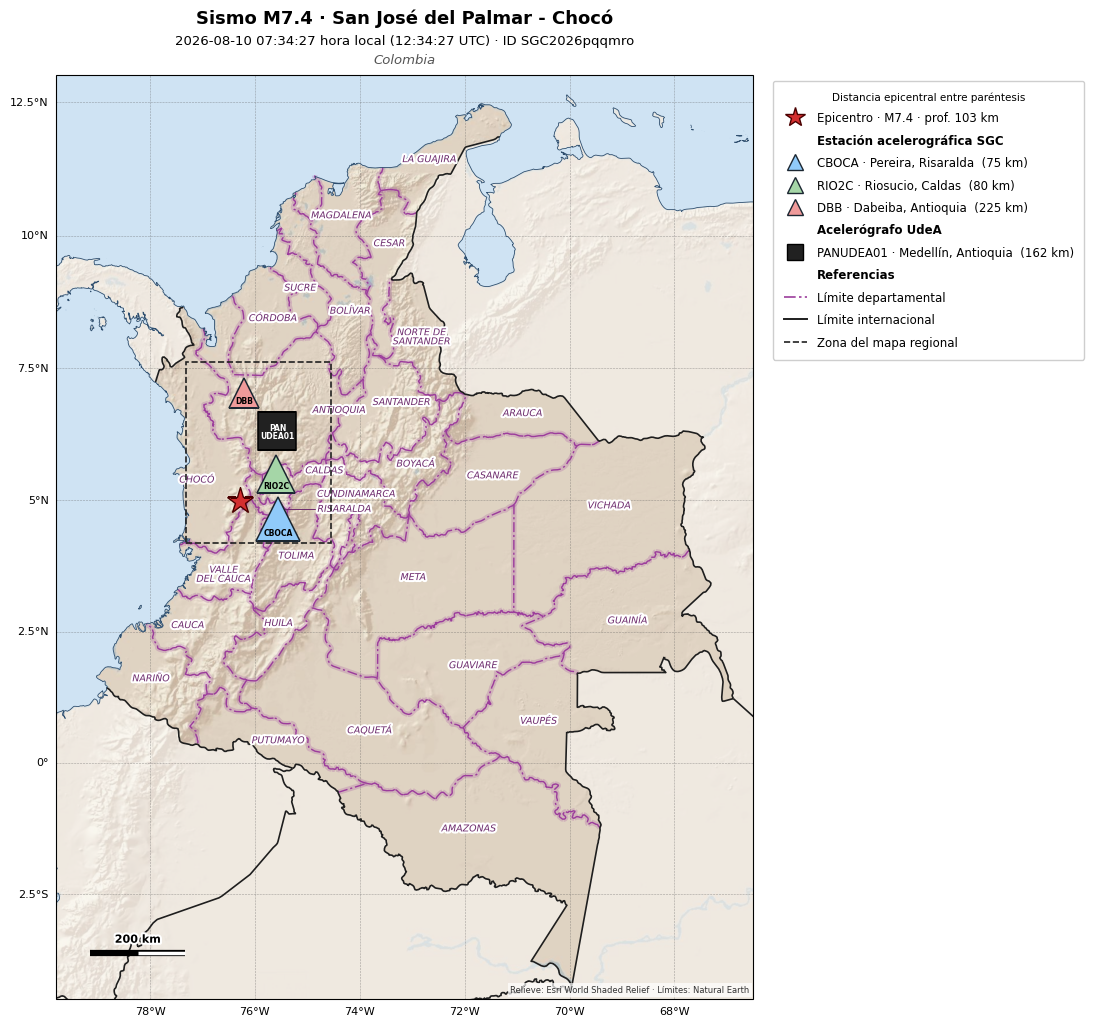

In [6]:
dibujar_mapa(EXTENSION_COLOMBIA, escala=0.85, nombre="mapa_colombia", figsize=(11, 12),
             etiqueta="Colombia", recuadro=EXTENSION_REGIONAL, municipios=False)

## §8 Mapa regional

Guardado: output\terremoto_choco\mapa\mapa_regional_terremoto_choco.png


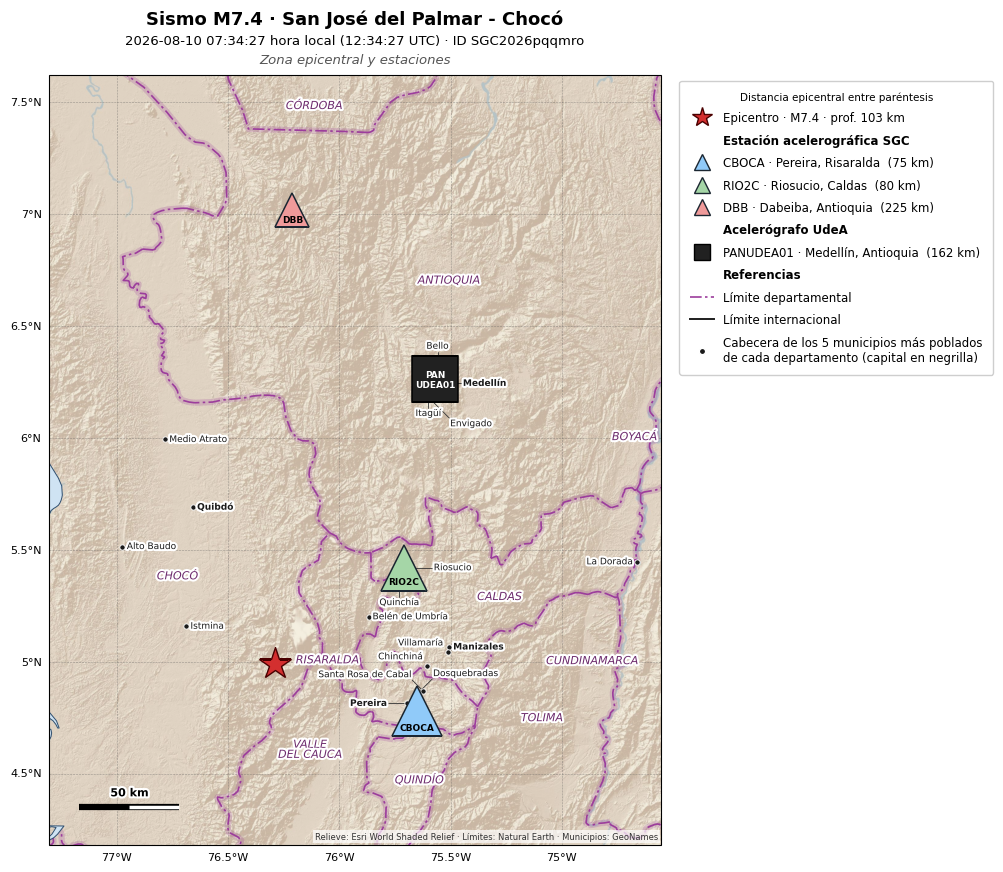

In [7]:
dibujar_mapa(EXTENSION_REGIONAL, escala=1.0, nombre="mapa_regional", figsize=(11, 10),
             etiqueta="Zona epicentral y estaciones")